## **LSTM (Long Short-Term Memory): Hotel Review Sentiment Classification**
**Individual contribution: Ummu Salma M. H. - IT23190870**

Task: classify a hotel review as **positive (1)** or **negative (0)**.

### **Step 0: Setup and libraries**

#### Settings and helper code

The next four cells contain everything this notebook needs besides the dataset: imports, the group settings, and helper functions for the data pipeline, evaluation and plots.

In [48]:
# Imports and dataset location 
import sys, re, json, time, pathlib, textwrap
from collections import Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from tensorflow import keras
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve)

layers = keras.layers

# Locate dataset and split files locally
DATA_NAME = "deceptive-opinion.csv"
SPLIT_NAME = "split_assignment.csv"
here = pathlib.Path.cwd().resolve()
search_roots = [here, here.parent, here.parent.parent]

data_candidates = [r / "dataset" / DATA_NAME for r in search_roots] + [r / DATA_NAME for r in search_roots]
DATA_PATH = next((p for p in data_candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Cannot find {DATA_NAME}. Ensure dataset/{DATA_NAME} exists.")

split_candidates = [r / "shared" / SPLIT_NAME for r in search_roots] + [r / SPLIT_NAME for r in search_roots]
SPLIT_PATH = next((p for p in split_candidates if p.exists()), None)
if SPLIT_PATH is None:
    raise FileNotFoundError(f"Cannot find {SPLIT_NAME}. Ensure shared/{SPLIT_NAME} exists.")

# Root folder for LSTM
LSTM_ROOT = here
RESULTS = LSTM_ROOT / "results"
RESULTS.mkdir(exist_ok=True)

print("Dataset:", DATA_PATH)
print("Split file:", SPLIT_PATH)
print("Results folder:", RESULTS)


Dataset: C:\USH_\The White Hat\DL Assignment\Deep-Learning---Assignment\dataset\deceptive-opinion.csv
Split file: C:\USH_\The White Hat\DL Assignment\Deep-Learning---Assignment\shared\split_assignment.csv
Results folder: C:\USH_\The White Hat\DL Assignment\Deep-Learning---Assignment\lstm\results


In [49]:
# Group settings
SEED = 42

# Labels
LABEL_COLUMN = "polarity"
LABEL_MAP = {"negative": 0, "positive": 1}

# Text -> integer sequences
VOCAB_SIZE = 5000 # total no of ids
MAX_LEN = 300 # tokens per review after cleaning
PAD_TOKEN, OOV_TOKEN = "<PAD>", "<OOV>"
PADDING = "pre" # padding at begining
TRUNCATING = "post" # long reviews keep their first MAX_LEN tokens

# Training
EMBED_DIM = 64
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5 # EarlyStopping patience, monitoring validation loss
MONITOR = "val_loss"
THRESHOLD = 0.5 # probability cut-off used for every model's test metrics

# Split file loaded directly from shared/split_assignment.csv
split_df = pd.read_csv(SPLIT_PATH)
VAL_IDS = set(split_df.loc[split_df["split"] == "val", "row_id"])
TEST_IDS = set(split_df.loc[split_df["split"] == "test", "row_id"])

keras.utils.set_random_seed(SEED) # seeds Python, NumPy and TensorFlow
print("TensorFlow", tf.__version__, ", Keras", keras.__version__, ", seed", SEED)
print("Devices:", [d.device_type for d in tf.config.list_physical_devices()])
print(f"Loaded fixed split: {len(VAL_IDS)} validation rows, {len(TEST_IDS)} test rows.")


TensorFlow 2.21.0 , Keras 3.15.1 , seed 42
Devices: ['CPU']
Loaded fixed split: 160 validation rows, 160 test rows.


In [50]:
# Data pipeline
# Leakage rule: vocabulary and class weights are built from TRAINING rows only.
# Validation/test are transformed using the training vocabulary.

def load_labelled_data() -> pd.DataFrame:
    """Duplicates removed before splitting → prevents train/test leakage."""
    df = pd.read_csv(DATA_PATH)
    df["row_id"] = np.arange(len(df)) # original row ID
    df["text"] = df["text"].astype(str).str.strip()
    df["label"] = df[LABEL_COLUMN].map(LABEL_MAP)
    assert df["label"].notna().all(), "unexpected label value"
    df["label"] = df["label"].astype(int)
    df = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)
    return df[["row_id", "text", "label", "hotel", "deceptive", "source"]]


def assign_split(df: pd.DataFrame) -> np.ndarray:
    if not (VAL_IDS | TEST_IDS) <= set(df["row_id"]):
        raise ValueError("The fixed validation/test ids do not match this dataset. Was the CSV changed?")
    return np.where(df["row_id"].isin(TEST_IDS), "test", np.where(df["row_id"].isin(VAL_IDS), "val", "train"))


# Text cleaning: Same cleaning for all models; no fitting
_HTML = re.compile(r"<[^>]+>")
_URL = re.compile(r"(https?://\S+|www\.\S+)")
_CONTRACTIONS = [
    (r"\bwon't\b", "will not"), (r"\bcan't\b", "can not"), (r"\bcannot\b", "can not"),
    (r"n't\b", " not"), (r"'re\b", " are"), (r"'ve\b", " have"), (r"'ll\b", " will"),
    (r"'d\b", " would"), (r"'m\b", " am"), (r"'s\b", ""),
]
_NON_LETTER = re.compile(r"[^a-z\s]")
_SPACES = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """lowercase -> remove HTML -> remove URLs -> expand contractions -> remove non-letters -> normalize spaces
    IMPORTANT: Keep negation words (not, no, never)
    """
    text = text.lower().replace("’", "'")
    text = _HTML.sub(" ", text)
    text = _URL.sub(" ", text)
    for pattern, replacement in _CONTRACTIONS:
        text = re.sub(pattern, replacement, text)
    text = _NON_LETTER.sub(" ", text) # digits, punctuation, symbols
    return _SPACES.sub(" ", text).strip()


def build_vocab(train_token_lists, vocab_size: int = VOCAB_SIZE) -> dict:
    """Most frequent TRAINING words -> ids"""
    counts = Counter(tok for tokens in train_token_lists for tok in tokens)
    words = [w for w, _ in counts.most_common(vocab_size - 2)]
    vocab = {PAD_TOKEN: 0, OOV_TOKEN: 1}
    vocab.update({w: i + 2 for i, w in enumerate(words)})
    return vocab


def encode(tokens, vocab: dict) -> list:
    oov = vocab[OOV_TOKEN]
    return [vocab.get(t, oov) for t in tokens]


def decode(ids, vocab: dict, skip_pad: bool = True) -> list:
    """Inverse of encode: ids -> words"""
    inverse = {i: w for w, i in vocab.items()}
    return [inverse[int(i)] for i in ids if not (skip_pad and int(i) == 0)]


def pad(sequences, max_len: int = MAX_LEN) -> np.ndarray:
    out = np.zeros((len(sequences), max_len), dtype="int32")
    for i, seq in enumerate(sequences):
        seq = seq[:max_len] if TRUNCATING == "post" else seq[-max_len:]
        if PADDING == "pre":
            out[i, max_len - len(seq):] = seq
        else:
            out[i, :len(seq)] = seq
    return out


def compute_class_weights(y_train) -> dict:
    """weight_c = n_samples / (n_classes * n_samples_in_class_c)"""
    classes, counts = np.unique(y_train, return_counts=True)
    return {int(c): float(len(y_train) / (len(classes) * n)) for c, n in zip(classes, counts)}


@dataclass
class Data:
    X_train: np.ndarray
    y_train: np.ndarray
    X_val: np.ndarray
    y_val: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    vocab: dict
    class_weight: dict
    train_df: pd.DataFrame # raw + cleaned text, kept for EDA / error analysis
    val_df: pd.DataFrame
    test_df: pd.DataFrame


def prepare_data() -> Data:
    df = load_labelled_data()
    df["split"] = assign_split(df)
    df["clean"] = df["text"].map(clean_text)
    df["tokens"] = df["clean"].str.split()

    parts = {name: g.reset_index(drop=True) for name, g in df.groupby("split")}
    vocab = build_vocab(parts["train"]["tokens"].tolist())          # <- TRAIN ONLY

    def to_xy(part: pd.DataFrame):
        seqs = [encode(tokens, vocab) for tokens in part["tokens"]]
        return pad(seqs), part["label"].to_numpy(dtype="int32")

    X_train, y_train = to_xy(parts["train"])
    X_val, y_val = to_xy(parts["val"])
    X_test, y_test = to_xy(parts["test"])
    return Data(X_train, y_train, X_val, y_val, X_test, y_test, vocab, compute_class_weights(y_train), parts["train"], parts["val"], parts["test"])

In [51]:
# Evaluation helpers
# Positive class = 1

def compute_metrics(y_true, y_prob, threshold: float = THRESHOLD) -> dict:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        # per-class view, needed for the error analysis
        "negative_precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "negative_recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "negative_f1": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def bootstrap_ci(y_true, y_prob, n_boot: int = 2000, seed: int = SEED) -> dict:
    """95% bootstrap interval for accuracy / F1 / ROC-AUC on the test set.
    It only describes how uncertain the (small) test set makes the numbers. It is NOT used to tune anything."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).ravel()
    rng = np.random.default_rng(seed)
    out = {"accuracy": [], "f1": [], "roc_auc": []}
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        m = compute_metrics(y_true[idx], y_prob[idx])
        for k in out:
            out[k].append(m[k])
    return {k: [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] for k, v in out.items()}


def save_result(path, model_name: str, test_metrics: dict, *, training_time_sec: float,
                trainable_params: int, total_params: int, epochs_run: int, best_epoch: int,
                extra: dict = None) -> dict:
    row = {
        "model": model_name,
        "accuracy": test_metrics["accuracy"], "precision": test_metrics["precision"],
        "recall": test_metrics["recall"], "f1": test_metrics["f1"], "roc_auc": test_metrics["roc_auc"],
        "training_time_sec": training_time_sec,
        "trainable_params": trainable_params, "total_params": total_params,
        "epochs_run": epochs_run, "best_epoch": best_epoch,
        "seed": SEED, "max_len": MAX_LEN, "vocab_size": VOCAB_SIZE,
        "embed_dim": EMBED_DIM, "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE, "threshold": THRESHOLD,
        "confusion_matrix": {k: test_metrics[k] for k in ("tn", "fp", "fn", "tp")},
    }
    if extra:
        row.update(extra)
    with open(path, "w") as f:
        json.dump(row, f, indent=2)
    return row


# Plot helpers
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
BLUE_RAMP = LinearSegmentedColormap.from_list("blue_seq", ["#cde2fb", "#3987e5", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.edgecolor": GRID, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save_and_show(fig, path=None, show=True):
    fig.tight_layout()
    if path:
        fig.savefig(path)
    if show:
        plt.show()
    plt.close(fig)


def plot_curve(history: dict, metric: str, model_name: str, best_epoch=None, path=None, show=True):
    """Training vs validation curve for 'accuracy' or 'loss'"""
    train, val = history[metric], history["val_" + metric]
    epochs = np.arange(1, len(train) + 1)
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(epochs, train, color=BLUE, label="Training")
    ax.plot(epochs, val, color=ORANGE, label="Validation")
    for series, color, name in ((train, BLUE, "Training"), (val, ORANGE, "Validation")):
        ax.plot(epochs[-1], series[-1], "o", color=color, markersize=6, markeredgecolor="white", markeredgewidth=1.5)
        ax.annotate(name, (epochs[-1], series[-1]), xytext=(8, 0), textcoords="offset points", va="center", color=INK2, fontsize=10)
    if best_epoch:
        ax.axvline(best_epoch, color=INK2, linestyle=":", linewidth=1.2)
        ax.text(best_epoch, ax.get_ylim()[1], f" best epoch {best_epoch}", color=INK2, fontsize=9, va="top", ha="left")
    ax.set_xlim(0.7, epochs[-1] + 0.15 * max(epochs[-1], 6))
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"{model_name}: training vs validation {metric}", loc="left")
    ax.legend(loc="best")
    save_and_show(fig, path, show)


def plot_confusion_matrix(cm: np.ndarray, model_name: str, path=None, show=True):
    """2x2 confusion matrix (rows = true class, columns = predicted class)."""
    labels = ["Negative", "Positive"]
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    ax.imshow(cm, cmap=BLUE_RAMP, vmin=0, vmax=cm.max())
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            dark = cm[i, j] > cm.max() * 0.55
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=18,
                    fontweight="bold", color="white" if dark else INK)
    ax.set_xticks([0, 1], labels)
    ax.set_yticks([0, 1], labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{model_name}: confusion matrix (test)", loc="left")
    for s in ax.spines.values():
        s.set_visible(False)
    save_and_show(fig, path, show)


def plot_roc(y_true, y_prob, auc: float, model_name: str, threshold: float = 0.5, path=None, show=True):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5.2, 4.8))
    ax.plot([0, 1], [0, 1], color=INK2, linestyle="--", linewidth=1.2)
    ax.text(0.55, 0.47, "chance (AUC = 0.50)", color=INK2, fontsize=9, rotation=33)
    ax.plot(fpr, tpr, color=BLUE)
    k = np.argmin(np.abs(thr - threshold)) # operating point at the 0.5 cut-off
    ax.plot(fpr[k], tpr[k], "o", color=ORANGE, markersize=8, markeredgecolor="white", markeredgewidth=1.5)
    ax.annotate(f"threshold {threshold}", (fpr[k], tpr[k]), xytext=(10, -14),
                textcoords="offset points", color=INK2, fontsize=9)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{model_name}: ROC curve (test), AUC = {auc:.3f}", loc="left")
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_aspect("equal")
    save_and_show(fig, path, show)


def plot_probability_hist(y_true, y_prob, model_name: str, threshold: float = 0.5, path=None, show=True):
    """How confident is the model? Predicted P(positive), split by the true class (stacked bars)."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob).ravel()
    bins = np.linspace(0, 1, 21)
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.hist([y_prob[y_true == 1], y_prob[y_true == 0]], bins=bins, stacked=True,
            color=[BLUE, ORANGE], label=["True positive reviews", "True negative reviews"],
            edgecolor="white", linewidth=1.5)
    ax.axvline(threshold, color=INK2, linestyle=":", linewidth=1.2)
    ax.set_xlabel("Predicted probability of positive")
    ax.set_ylabel("Number of test reviews")
    ax.set_title(f"{model_name}: confidence on the test set", loc="left")
    ax.legend(loc="upper center")
    save_and_show(fig, path, show)

### **Step 1: Data audit** (cleaning checks on raw file)

Check missing values, duplicates, encoding problems and outliers. These are hygiene checks; only exact duplicate reviews are removed, and the audit is done before splitting so all models use the same cleaned data.

In [52]:
raw = pd.read_csv(DATA_PATH)  # the file exactly as given

text = raw["text"].astype(str).str.strip()
cleaned = text.map(clean_text)
print(f"Rows: {len(raw):,}, columns: {list(raw.columns)}\n")

print("MISSING VALUES / BLANK TEXT")
print(pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "blank": [(raw[c].astype(str).str.strip() == "").sum() for c in raw.columns]
}).to_string())
print("\nLabel values found:", raw["polarity"].value_counts().to_dict(), ", encoded with", LABEL_MAP)

print("\nDUPLICATES")
print("  exact duplicate rows (all columns):", raw.duplicated().sum())
print("  duplicate review texts:", text.duplicated().sum())
print("  duplicates after cleaning (ignoring case / punctuation / digits):", cleaned.duplicated().sum())
print("  duplicate texts with conflicting labels:", raw.assign(t=text).groupby("t")["polarity"].nunique().gt(1).sum())
print("  extra reviews that only share their first 200 characters with another review:", cleaned.str[:200].duplicated().sum() - cleaned.duplicated().sum())

print("\nENCODING")
print("  reviews with non-ASCII characters:", sum(any(ord(ch) > 127 for ch in s) for s in text))
print("  replacement characters (U+FFFD):", text.str.contains("\ufffd").sum(), ", mojibake patterns:", text.str.contains("Ã|â€|Â").sum())
print("  reviews containing HTML tags:", text.str.contains(r"<[^>]+>").sum(), ", URLs:", text.str.contains(r"https?://|www\.").sum(), ", digits:", text.str.contains(r"\d").sum())

Rows: 1,600, columns: ['deceptive', 'hotel', 'polarity', 'source', 'text']

MISSING VALUES / BLANK TEXT
          dtype  missing  blank
deceptive   str        0      0
hotel       str        0      0
polarity    str        0      0
source      str        0      0
text        str        0      0

Label values found: {'positive': 800, 'negative': 800} , encoded with {'negative': 0, 'positive': 1}

DUPLICATES
  exact duplicate rows (all columns): 4
  duplicate review texts: 4
  duplicates after cleaning (ignoring case / punctuation / digits): 4
  duplicate texts with conflicting labels: 0
  extra reviews that only share their first 200 characters with another review: 1

ENCODING
  reviews with non-ASCII characters: 0
  replacement characters (U+FFFD): 0 , mojibake patterns: 0
  reviews containing HTML tags: 0 , URLs: 2 , digits: 820


OUTLIERS: review length in tokens (IQR rule)
  min 25 , Q1 88 , median 128 , Q3 182 , max 795
  fences: lower -53, upper 324 -> 0 reviews below, 75 above (4.7%)
  reviews that are empty after cleaning: 0


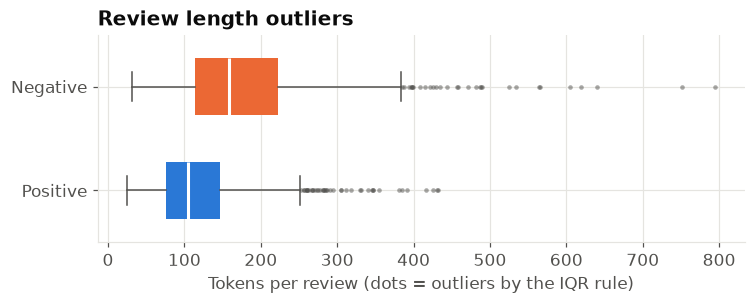

In [53]:
tokens = cleaned.str.split().map(len)
q1, q3 = tokens.quantile([0.25, 0.75])
lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
print("OUTLIERS: review length in tokens (IQR rule)")
print(f"  min {tokens.min()} , Q1 {q1:.0f} , median {tokens.median():.0f} , Q3 {q3:.0f} , max {tokens.max()}")
print(f"  fences: lower {lower:.0f}, upper {upper:.0f} -> {int((tokens < lower).sum())} reviews below, "
      f"{int((tokens > upper).sum())} above ({100 * (tokens > upper).mean():.1f}%)")
print(f"  reviews that are empty after cleaning: {int((tokens == 0).sum())}")

fig, ax = plt.subplots(figsize=(7, 2.9))
groups = [tokens[raw["polarity"] == k] for k in ("positive", "negative")]
box_style = dict(widths=0.55, patch_artist=True, flierprops=dict(marker="o", markersize=3, markerfacecolor=INK2, markeredgecolor="none", alpha=0.5), medianprops=dict(color="white", linewidth=2), whiskerprops=dict(color=INK2), capprops=dict(color=INK2))
try:
    bp = ax.boxplot(groups, orientation="horizontal", **box_style)
except TypeError:                                   
    bp = ax.boxplot(groups, vert=False, **box_style)
for box, colour in zip(bp["boxes"], (BLUE, ORANGE)):
    box.set(facecolor=colour, edgecolor="none")
ax.set_yticks([1, 2], ["Positive", "Negative"])
ax.set_xlabel("Tokens per review (dots = outliers by the IQR rule)")
ax.set_title("Review length outliers", loc="left")
save_and_show(fig, RESULTS / "lstm_audit_length_outliers.png")

### **Step 2: Data, labels and split**

* Labels: positive = 1, negative = 0
* Remove exact duplicates before splitting.
* Fixed stratified 80/10/10 split, same rows for all four models.

In [54]:
data = prepare_data()

def split_table(name, y):
    return {"split": name, "reviews": len(y), "positive": int(y.sum()), "negative": int((1 - y).sum()), "% positive": round(100 * y.mean(), 1)}

pd.DataFrame([split_table("train (80%)", data.y_train), split_table("validation (10%)", data.y_val), split_table("test (10%)", data.y_test)])

,split,reviews,positive,negative,% positive
0,train (80%),1276,640,636,50.2
1,validation (10%),160,80,80,50.0
2,test (10%),160,80,80,50.0


### **Step 3: Exploratory data analysis** (training set)

EDA is performed on TRAIN only to avoid influencing the validation/test sets.

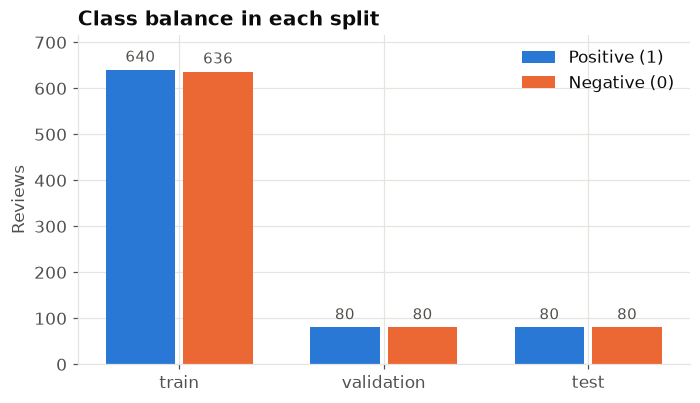

In [55]:
splits = {"train": data.y_train, "validation": data.y_val, "test": data.y_test}
x, w = np.arange(len(splits)), 0.38
pos = [int(y.sum()) for y in splits.values()]
neg = [int((1 - y).sum()) for y in splits.values()]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
b1 = ax.bar(x - w / 2, pos, w - 0.04, color=BLUE, label="Positive (1)")
b2 = ax.bar(x + w / 2, neg, w - 0.04, color=ORANGE, label="Negative (0)")
for bars in (b1, b2):
    ax.bar_label(bars, padding=3, color=INK2, fontsize=10)
ax.set_xticks(x, list(splits))
ax.set_ylabel("Reviews")
ax.set_ylim(0, max(pos + neg) * 1.12)
ax.set_title("Class balance in each split", loc="left")
ax.legend(loc="upper right")
save_and_show(fig, RESULTS / "lstm_eda_class_balance.png")

In [56]:
from collections import Counter

tr = data.train_df.assign(n_tokens=lambda d: d["tokens"].map(len), label_name=lambda d: d["label"].map({1: "positive", 0: "negative"}))
print("Tokens per review by class (training set):")
print(tr.groupby("label_name")["n_tokens"].describe()[["count", "mean", "50%", "max"]].round(1).to_string())

NEGATION = {"not", "no", "never", "nothing", "nobody", "none", "without"}
has_negation = tr["tokens"].map(lambda t: bool(NEGATION & set(t)))
share = tr.assign(neg=has_negation).groupby("label_name")["neg"].mean().mul(100).round(1)
print("\n% of reviews containing a negation word:", share.to_dict())

print("\nReview origin x label (training set):")
print(pd.crosstab(tr["label_name"], tr["deceptive"]).to_string())
print("\nMost frequent tokens (stop-words included):", [w for w, _ in Counter(t for toks in tr["tokens"] for t in toks).most_common(12)])

Tokens per review by class (training set):
            count   mean    50%    max
label_name                            
negative    636.0  180.4  159.0  795.0
positive    640.0  118.8  103.0  432.0

% of reviews containing a negation word: {'negative': 95.8, 'positive': 59.7}

Review origin x label (training set):
deceptive   deceptive  truthful
label_name                     
negative          319       317
positive          322       318

Most frequent tokens (stop-words included): ['the', 'and', 'to', 'i', 'a', 'was', 'in', 'hotel', 'of', 'we', 'not', 'for']


In [57]:
# Length-only baseline: choose threshold on TRAIN, evaluate on VALIDATION.
# Test set untouched.
from sklearn.metrics import roc_auc_score

len_train = data.train_df["tokens"].map(len).to_numpy()
len_val = data.val_df["tokens"].map(len).to_numpy()
candidates = np.unique(len_train)
train_acc = [((len_train <= t).astype(int) == data.y_train).mean() for t in candidates]
T = candidates[int(np.argmax(train_acc))]
print(f"Length-only rule 'longer than {T} tokens -> negative': train accuracy {max(train_acc):.3f}, "
      f"validation accuracy {((len_val <= T).astype(int) == data.y_val).mean():.3f}, "
      f"validation ROC-AUC {roc_auc_score(data.y_val, -len_val):.3f}  (chance = 0.500)")

Length-only rule 'longer than 120 tokens -> negative': train accuracy 0.672, validation accuracy 0.675, validation ROC-AUC 0.703  (chance = 0.500)


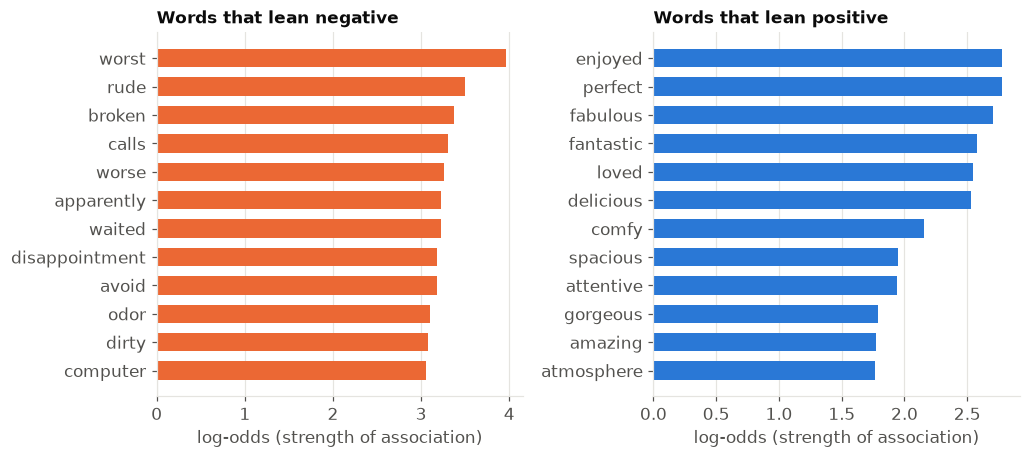

In [58]:
# Which words separate positive from negative reviews? (display only: common stop-words hidden here,
# but they are NOT removed from the model input)
STOP = set("a an the and or but of to in on at for with from by as is was were are be been am it its this that "
           "these those i me my we our you your they their he she him her them us so very just also than then "
           "there here had have has do did does would could will".split())
docs = {k: [set(t) - STOP for t in tr.loc[tr["label"] == k, "tokens"]] for k in (1, 0)}
n_docs = {k: len(v) for k, v in docs.items()}
doc_freq = {k: Counter(word for d in docs[k] for word in d) for k in (1, 0)}
score = {word: np.log((doc_freq[1][word] + 1) / (n_docs[1] + 2)) - np.log((doc_freq[0][word] + 1) / (n_docs[0] + 2))
         for word in set(doc_freq[1]) | set(doc_freq[0]) if doc_freq[1][word] + doc_freq[0][word] >= 20}
ranked = sorted(score.items(), key=lambda kv: kv[1])
panels = ((ranked[:12], ORANGE, "Words that lean negative"), (ranked[::-1][:12], BLUE, "Words that lean positive"))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.3))
for ax, (items, colour, title) in zip(axes, panels):
    words, values = zip(*items)
    ax.barh(np.arange(len(words)), np.abs(values), color=colour, height=0.65)
    ax.set_yticks(np.arange(len(words)), words)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("log-odds (strength of association)")
    ax.set_title(title, loc="left", fontsize=11)
save_and_show(fig, RESULTS / "lstm_eda_distinctive_words.png")

### **Step 4: Feature engineering** (turning text into numbers)

Convert cleaned review text into numeric sequences for the neural network.

The same preprocessing is used for all four models:
**cleaning → tokenization → vocabulary → integer encoding → padding/truncation → embedding.**

In [59]:
sample = data.train_df.iloc[3]
ids = encode(sample["tokens"], data.vocab)
padded = data.X_train[3] # the same review as it enters the model

print("RAW     :", sample["text"][:160].replace("\n", " "))
print("CLEAN   :", sample["clean"][:160])
print("TOKENS  :", sample["tokens"][:10])
print("IDS     :", ids[:10])
print("DECODED :", decode(ids[:10], data.vocab), "  <- ids back to words (decoding)")
print(f"PADDED  : {len(padded)} ids, {int((padded == 0).sum())} leading zeros, last 8 ids = {padded[-8:].tolist()}")
assert decode(padded, data.vocab) == decode(ids[:MAX_LEN], data.vocab)   # padding lost nothing
print("Round trip OK: decode(padded input) equals the encoded review (first MAX_LEN tokens)")

RAW     : Ok, so first trip to chicago and I was a litlle worried about the hotel and the location, finally I decided on the CONRAD and wath a good experience i had, I bo
CLEAN   : ok so first trip to chicago and i was a litlle worried about the hotel and the location finally i decided on the conrad and wath a good experience i had i booke
TOKENS  : ['ok', 'so', 'first', 'trip', 'to', 'chicago', 'and', 'i', 'was', 'a']
IDS     : [484, 42, 92, 145, 4, 25, 3, 5, 7, 6]
DECODED : ['ok', 'so', 'first', 'trip', 'to', 'chicago', 'and', 'i', 'was', 'a']   <- ids back to words (decoding)
PADDED  : 300 ids, 196 leading zeros, last 8 ids = [206, 504, 37, 135, 3, 30, 433, 9]
Round trip OK: decode(padded input) equals the encoded review (first MAX_LEN tokens)


Tokens per training review: median 129, 95th percentile 318, max 795
MAX_LEN = 300: 6.1% of training reviews are truncated
Unique training words: 8,445. VOCAB_SIZE = 5,000 covers 98.2% of training tokens; 2.9% of validation tokens map to <OOV>
  train      X (1276, 300) int32 , y (1276,)
  validation X (160, 300) int32 , y (160,)
  test       X (160, 300) int32 , y (160,)
Share of padding zeros in the training matrix: 52.1%


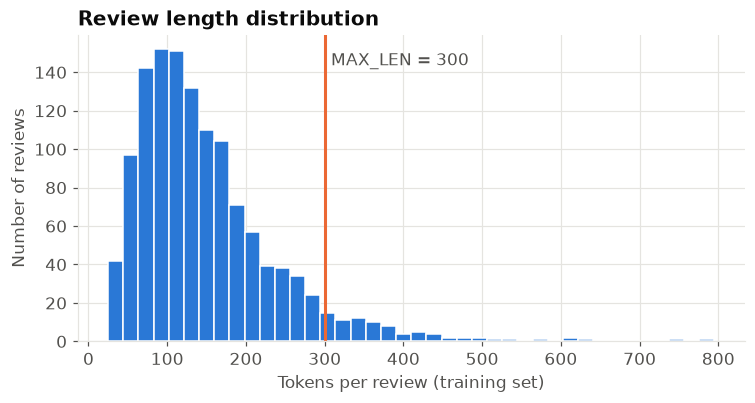

In [60]:
train_len = data.train_df["tokens"].map(len)
print(f"Tokens per training review: median {int(train_len.median())}, "
      f"95th percentile {int(np.percentile(train_len, 95))}, max {train_len.max()}")
print(f"MAX_LEN = {MAX_LEN}: {100*(train_len > MAX_LEN).mean():.1f}% of training reviews are truncated")

counts = Counter(t for toks in data.train_df["tokens"] for t in toks)
covered = sum(c for _, c in counts.most_common(VOCAB_SIZE - 2)) / sum(counts.values())
val_tokens = [t for toks in data.val_df["tokens"] for t in toks]     # validation only, for the OOV rate
val_oov = np.mean([t not in data.vocab for t in val_tokens])
print(f"Unique training words: {len(counts):,}. VOCAB_SIZE = {VOCAB_SIZE:,} covers "
      f"{100*covered:.1f}% of training tokens; {100*val_oov:.1f}% of validation tokens map to <OOV>")

for name, X, y in [("train", data.X_train, data.y_train), ("validation", data.X_val, data.y_val), ("test", data.X_test, data.y_test)]:
    print(f"  {name:10s} X {X.shape} {X.dtype} , y {y.shape}")
print(f"Share of padding zeros in the training matrix: {100 * (data.X_train == 0).mean():.1f}%")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(train_len, bins=40, color=BLUE, edgecolor="white", linewidth=1)
ax.axvline(MAX_LEN, color=ORANGE, linewidth=2)
ax.text(MAX_LEN + 8, ax.get_ylim()[1] * 0.9, f"MAX_LEN = {MAX_LEN}", color=INK2)
ax.set_xlabel("Tokens per review (training set)"); ax.set_ylabel("Number of reviews")
ax.set_title("Review length distribution", loc="left")
save_and_show(fig, RESULTS / "lstm_eda_review_length.png")

### **Step 5: Class weights**

Class weights are calculated from the training labels to handle class imbalance.

In [61]:
print("Class weights :", {k: round(v, 4) for k, v in data.class_weight.items()})

Class weights : {0: 1.0031, 1: 0.9969}


## LSTM Model & Architecture Comparison (Unidirectional vs. Bidirectional)

### Objective

Compare a **unidirectional LSTM** with a **bidirectional LSTM** for hotel review sentiment classification.

Both models use the same preprocessing, data split, hyperparameters, and training procedure. The architectural difference is how the sequence is processed.

### Architecture

Input (300 token IDs)
→ Embedding(5000, 64)
→ LSTM(64)
→ Dropout(0.5)
→ Dense(32, ReLU)
→ Dropout(0.3)
→ Dense(1, Sigmoid)

### Unidirectional LSTM

Processes the sequence in one direction:

Input → → → → →

### Bidirectional LSTM

Processes the sequence in both forward and backward directions:

Forward:  → → → → →
Backward: ← ← ← ← ←

The forward and backward representations are combined before the classification layers.

In [62]:
def build_unidirectional_lstm(units=64, embed_dim=EMBED_DIM, dropout1=0.5, dense_units=32, dropout2=0.3):
    """Unidirectional LSTM: processes sequence strictly forward (past to future)."""
    return keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(VOCAB_SIZE, embed_dim),                
        layers.LSTM(units, return_sequences=False),             
        layers.Dropout(dropout1),                               
        layers.Dense(dense_units, activation="relu"),           
        layers.Dropout(dropout2),                               
        layers.Dense(1, activation="sigmoid"), # Binary output probability P(positive)
    ], name="unidirectional_lstm_sentiment")

def build_bidirectional_lstm(units=64, embed_dim=EMBED_DIM, dropout1=0.5, dense_units=32, dropout2=0.3):
    """Bidirectional LSTM: processes sequence in both forward and backward directions."""
    return keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(VOCAB_SIZE, embed_dim),                
        layers.Bidirectional(layers.LSTM(units, return_sequences=False)), 
        layers.Dropout(dropout1),                               
        layers.Dense(dense_units, activation="relu"),           
        layers.Dropout(dropout2),                              
        layers.Dense(1, activation="sigmoid"), # Binary output probability P(positive)
    ], name="bidirectional_lstm_sentiment")

# Default build function 
def build_lstm():
    return build_unidirectional_lstm()

def n_params(weights):
    return int(sum(np.prod(w.shape) for w in weights))

# Instantiate and inspect both architectures
uni_model = build_unidirectional_lstm()
bi_model = build_bidirectional_lstm()

print("=" * 75)
print("1. UNIDIRECTIONAL LSTM SUMMARY")
print("=" * 75)
uni_model.summary()

print("\n" + "=" * 75)
print("2. BIDIRECTIONAL LSTM SUMMARY")
print("=" * 75)
bi_model.summary()

uni_bd = {l.name: n_params(l.trainable_weights) for l in uni_model.layers if l.trainable_weights}
bi_bd = {l.name: n_params(l.trainable_weights) for l in bi_model.layers if l.trainable_weights}
print(f"\nUnidirectional Trainable params: {uni_bd} , Total: {uni_model.count_params():,}")
print(f"Bidirectional Trainable params: {bi_bd} , Total: {bi_model.count_params():,}")
print(f"Embedding share of parameters: {100 * next((v for k, v in uni_bd.items() if 'embedding' in k), 320000) / uni_model.count_params():.1f}%")


1. UNIDIRECTIONAL LSTM SUMMARY


Model: "unidirectional_lstm_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,137 (1.35 MB)

 Trainable params: 355,137 (1.35 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 300, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,209 (1.49 MB)

 Trainable params: 390,209 (1.49 MB)

 Non-trainable params: 0 (0.00 B)


Unidirectional Trainable params: {'embedding_2': 320000, 'lstm_2': 33024, 'dense_4': 2080, 'dense_5': 33} , Total: 355,137
Bidirectional Trainable params: {'embedding_3': 320000, 'bidirectional_1': 66048, 'dense_6': 4128, 'dense_7': 33} , Total: 390,209
Embedding share of parameters: 90.1%


## Training Configuration & Architectural Selection

Unidirectional and Bidirectional LSTM models are trained using the same training configuration and compared on the validation set. The test set is reserved for final evaluation.

 Setting | Value |
|---|---:|
| Optimizer | Adam |
| Learning rate | 0.001 |
| Loss | Binary cross-entropy |
| Batch size | 32 |
| Maximum epochs | 30 |
| Early stopping | `val_loss`, patience = 5 |
| Model selection | Validation set |

In [63]:
def save_training_outputs(model, history, train_time, epochs_run, best_epoch, model_name="LSTM"):
    # Save only the winning model's outputs for subsequent analysis
    model.save(RESULTS / "lstm_model.keras")
    (pd.DataFrame(history).rename_axis("epoch").reset_index().assign(epoch=lambda d: d.epoch + 1)
       .to_csv(RESULTS / "lstm_history.csv", index=False))
    (RESULTS / "lstm_training_info.json").write_text(json.dumps({
        "selected_architecture": model_name,
        "train_time_sec": train_time,
        "epochs_run": epochs_run,
        "best_epoch": best_epoch
    }))

def train_architecture(build_fn, model_title, seed=SEED, verbose=1):
    keras.utils.set_random_seed(seed)
    m = build_fn()
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    early_stop = keras.callbacks.EarlyStopping(
        monitor=MONITOR, patience=PATIENCE, restore_best_weights=True 
    )
    start = time.perf_counter()
    hist = m.fit(
        data.X_train, data.y_train,
        validation_data=(data.X_val, data.y_val),                     
        epochs=MAX_EPOCHS,                                            
        batch_size=BATCH_SIZE,                                       
        class_weight=data.class_weight,
        callbacks=[early_stop],
        verbose=verbose
    )
    elapsed = time.perf_counter() - start
    return m, hist.history, elapsed

def train_lstm(seed=SEED, verbose=1):
    """Convenience wrapper for seed robustness and external calls."""
    return train_architecture(build_lstm, "LSTM", seed=seed, verbose=verbose)

print("EXPERIMENT: UNIDIRECTIONAL LSTM VS. BIDIRECTIONAL LSTM ON VALIDATION SET")

print("\n>>> 1. Training Unidirectional LSTM...")
uni_model, uni_hist, uni_time = train_architecture(build_unidirectional_lstm, "Unidirectional LSTM", SEED, verbose=1)

print("\n>>> 2. Training Bidirectional LSTM...")
bi_model, bi_hist, bi_time = train_architecture(build_bidirectional_lstm, "Bidirectional LSTM", SEED, verbose=1)

# Compute validation metrics at best epoch for both architectures
def compute_metrics(y_true, y_prob, threshold=THRESHOLD):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        # per-class view, needed for the class-imbalance / error analysis
        "negative_precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "negative_recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "negative_f1": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }
def evaluate_validation(m, h, t):
    best_ep = int(np.argmin(h["val_loss"]))
    probs = m.predict(data.X_val, verbose=0).ravel()
    mets = compute_metrics(data.y_val, probs)
    return {
        "best_epoch": best_ep + 1,
        "val_loss": round(h["val_loss"][best_ep], 4),
        "val_accuracy": round(mets["accuracy"], 4),
        "val_f1": round(mets["f1"], 4),
        "val_roc_auc": round(mets["roc_auc"], 4),
        "training_time_sec": round(t, 2),
        "total_params": m.count_params(),
    }

uni_eval = evaluate_validation(uni_model, uni_hist, uni_time)
bi_eval = evaluate_validation(bi_model, bi_hist, bi_time)

comparison_table = pd.DataFrame([
    {"Architecture": "Unidirectional LSTM", **uni_eval},
    {"Architecture": "Bidirectional LSTM", **bi_eval}
]).set_index("Architecture")

print("\n" + "=" * 75)
print("VALIDATION SET ARCHITECTURAL COMPARISON RESULTS")
print("=" * 75)
print(comparison_table.to_string())

# Select best architecture (lowest val_loss / highest val_accuracy)
if uni_eval["val_loss"] <= bi_eval["val_loss"]:
    selected_name = "Unidirectional LSTM"
    model, history, train_time = uni_model, uni_hist, uni_time
    print(f"\n>> SELECTION: {selected_name} selected (lowest validation loss: {uni_eval['val_loss']}).")
else:
    selected_name = "Bidirectional LSTM"
    model, history, train_time = bi_model, bi_hist, bi_time
    print(f"\n>> SELECTION: {selected_name} selected (lowest validation loss: {bi_eval['val_loss']}).")

print("Per project guidelines, ONLY the winning model's artifacts will be saved to disk.")

epochs_run = len(history["loss"])
best_epoch = int(np.argmin(history["val_loss"])) + 1

# Save ONLY the best model's outputs
save_training_outputs(model, history, train_time, epochs_run, best_epoch, selected_name)
print(f"\nSuccessfully saved winning model ({selected_name}) to {RESULTS / 'lstm_model.keras'}.")
print(f"Saved training history to {RESULTS / 'lstm_history.csv'}.")
print(f"Epochs completed: {epochs_run} , Best epoch: {best_epoch} , Time: {train_time:.1f} s")


EXPERIMENT: UNIDIRECTIONAL LSTM VS. BIDIRECTIONAL LSTM ON VALIDATION SET

>>> 1. Training Unidirectional LSTM...
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.5972 - loss: 0.6853 - val_accuracy: 0.6438 - val_loss: 0.6119
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.8378 - loss: 0.4243 - val_accuracy: 0.9062 - val_loss: 0.3098
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9553 - loss: 0.1825 - val_accuracy: 0.9438 - val_loss: 0.1708
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9569 - loss: 0.1538 - val_accuracy: 0.9250 - val_loss: 0.2009
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9773 - loss: 0.0904 - val_accuracy: 0.9187 - val_loss: 0.3912
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9914 - loss: 0.0471 - val_accuracy: 0.9375 - val_loss: 0.1478
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.9961 - loss: 0.0298 - val_accuracy: 0.9563 - val_loss: 0.1

### **Step 8: Learning Curves** (training vs validation)

Learning curves show how the model performs on the training and validation sets during training.

- Training and validation performance improve together → good learning/generalization.
- Training performance keeps improving while validation loss increases → overfitting.
- Both training and validation performance remain poor → underfitting.

Early stopping helps prevent overfitting by restoring the model weights from the epoch with the lowest validation loss.

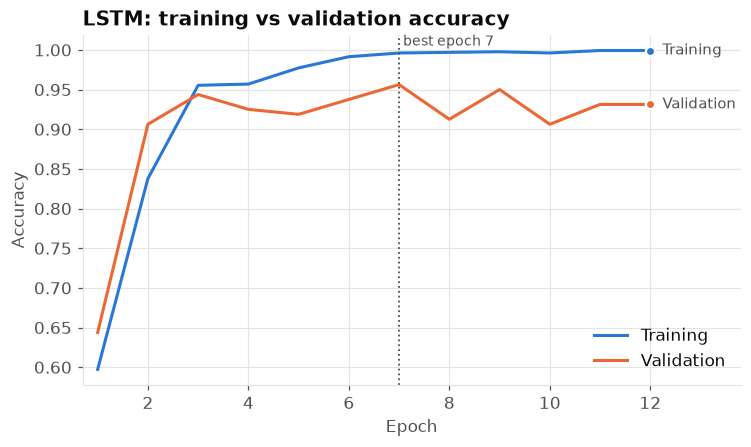

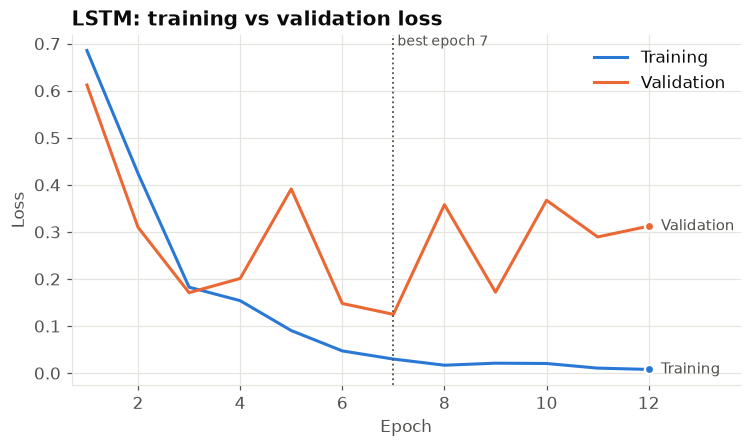

At the best epoch (7):  train acc 0.996 , val acc 0.956 , train loss 0.030 , val loss 0.125
Last epoch run (12):     train acc 0.999 , val acc 0.931 , train loss 0.008 , val loss 0.312
Train-validation accuracy gap at best epoch: +0.040


In [64]:
plot_curve(history, "accuracy", "LSTM", best_epoch, RESULTS / "lstm_accuracy_curve.png")
plot_curve(history, "loss", "LSTM", best_epoch, RESULTS / "lstm_loss_curve.png")

b = best_epoch - 1
print(f"At the best epoch ({best_epoch}):  train acc {history['accuracy'][b]:.3f} , val acc {history['val_accuracy'][b]:.3f} "f", train loss {history['loss'][b]:.3f} , val loss {history['val_loss'][b]:.3f}")
print(f"Last epoch run ({epochs_run}):     train acc {history['accuracy'][-1]:.3f} , val acc {history['val_accuracy'][-1]:.3f} "f", train loss {history['loss'][-1]:.3f} , val loss {history['val_loss'][-1]:.3f}")
print(f"Train-validation accuracy gap at best epoch: {history['accuracy'][b] - history['val_accuracy'][b]:+.3f}")

### **Step 9: Final evaluation** (Test set)

Metrics use the group's shared definitions: threshold 0.5, and precision / recall / F1 for the **positive** class. ROC-AUC uses the raw probabilities.

In [65]:
y_prob = model.predict(data.X_test, verbose=0).ravel()
test = compute_metrics(data.y_test, y_prob)

trainable = n_params(model.trainable_weights)
total = model.count_params()

print(f"TEST  accuracy {test['accuracy']:.4f} , precision {test['precision']:.4f} , recall {test['recall']:.4f} "
      f", F1 {test['f1']:.4f} , ROC-AUC {test['roc_auc']:.4f}")
print(f"Confusion matrix:  TN={test['tn']}  FP={test['fp']}  FN={test['fn']}  TP={test['tp']}")
print(f"Trainable parameters: {trainable:,} (total {total:,}) , training time {train_time:.1f} s , epochs {epochs_run}")

ci = bootstrap_ci(data.y_test, y_prob)
print("\n95% bootstrap interval on test set: " + " , ".join(f"{k} {lo:.3f}-{hi:.3f}" for k, (lo, hi) in ci.items()))

TEST  accuracy 0.9313 , precision 0.9367 , recall 0.9250 , F1 0.9308 , ROC-AUC 0.9533
Confusion matrix:  TN=75  FP=5  FN=6  TP=74
Trainable parameters: 355,137 (total 355,137) , training time 44.0 s , epochs 12

95% bootstrap interval on test set: accuracy 0.887-0.969 , f1 0.886-0.969 , roc_auc 0.908-0.988


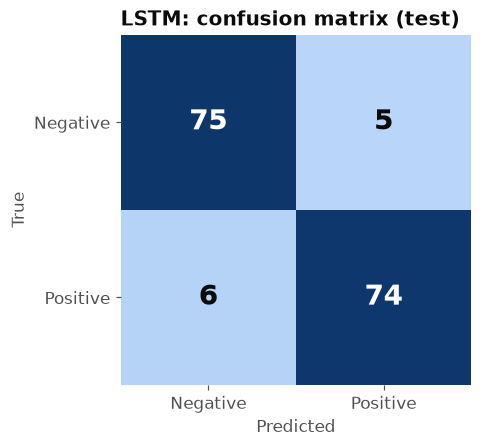

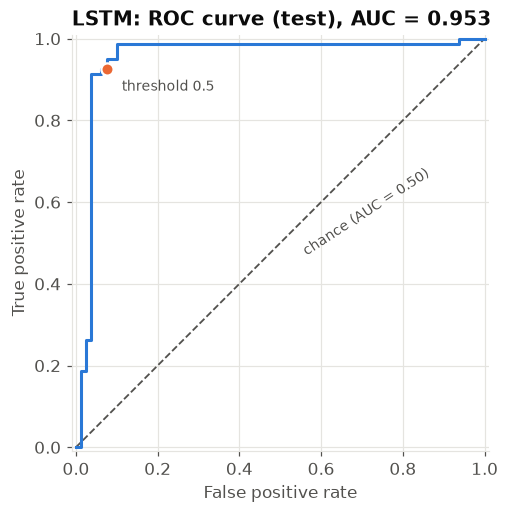

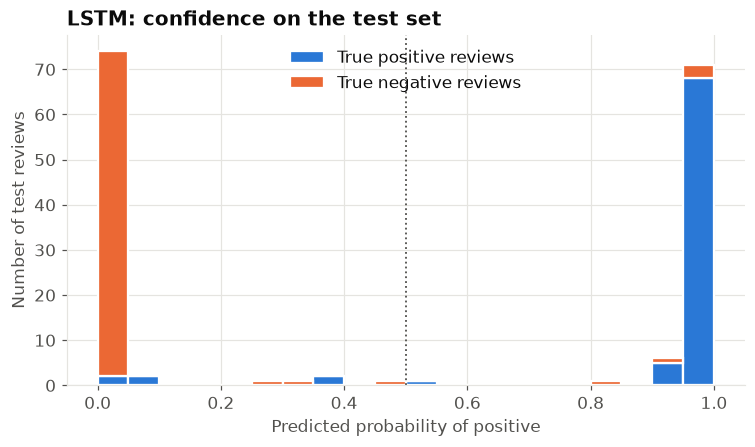

In [66]:
cm = np.array([[test["tn"], test["fp"]], [test["fn"], test["tp"]]])
plot_confusion_matrix(cm, "LSTM", RESULTS / "lstm_confusion_matrix.png")
plot_roc(data.y_test, y_prob, test["roc_auc"], "LSTM", THRESHOLD, RESULTS / "lstm_roc_curve.png")
plot_probability_hist(data.y_test, y_prob, "LSTM", THRESHOLD, RESULTS / "lstm_probability_hist.png")

In [67]:
model.save(RESULTS / "lstm_model.keras")

row = save_result(
    RESULTS / "lstm_metrics.json",
    "LSTM",
    test,
    training_time_sec=round(train_time, 2),
    trainable_params=trainable,
    total_params=total,
    epochs_run=epochs_run,
    best_epoch=best_epoch,
    extra={"bootstrap_95ci": ci, "class_weight": data.class_weight}
)

pred_df = data.test_df[["row_id", "label"]].assign( prob_positive=y_prob, pred=(y_prob >= THRESHOLD).astype(int) )
pred_df.to_csv(RESULTS / "lstm_test_predictions.csv", index=False)

### **Step 10: Error analysis**

Analyze the LSTM's incorrect predictions on the test set.

These patterns are descriptive only and are not used to modify the model.

In [68]:
err = data.test_df.copy()
err["prob"] = y_prob
err["pred"] = (y_prob >= THRESHOLD).astype(int)
err["outcome"] = np.select([(err.label == 1) & (err.pred == 1), (err.label == 0) & (err.pred == 0), (err.label == 0) & (err.pred == 1), (err.label == 1) & (err.pred == 0)],
                           ["TP", "TN", "FP", "FN"], default="")
err["wrong"] = err.label != err.pred
err["n_tokens"] = err["tokens"].map(len)
err["confidence"] = np.where(err.pred == 1, err.prob, 1 - err.prob)

print(err["outcome"].value_counts().reindex(["TP", "TN", "FP", "FN"]).to_string())
print()
per_class = pd.DataFrame({
    "class": ["Negative (0)", "Positive (1)"],
    "reviews": [(err.label == 0).sum(), (err.label == 1).sum()],
    "precision": [test["negative_precision"], test["precision"]],
    "recall": [test["negative_recall"], test["recall"]],
    "F1": [test["negative_f1"], test["f1"]]}).round(3)
print(per_class.to_string(index=False))

outcome
TP    74
TN    75
FP     5
FN     6

       class  reviews  precision  recall    F1
Negative (0)       80      0.926   0.938 0.932
Positive (1)       80      0.937   0.925 0.931


In [69]:
def rate_table(by, label):
    g = err.groupby(by)["wrong"].agg(reviews="size", errors="sum")
    g["error rate"] = (g["errors"] / g["reviews"]).round(3)
    g.index.name = label
    return g

print(rate_table("deceptive", "review origin"), "\n")
print(rate_table(err["n_tokens"] > MAX_LEN, f"longer than MAX_LEN={MAX_LEN}"), "\n")
print(rate_table(pd.cut(err["n_tokens"], [0, 100, 200, 10_000], labels=["<=100", "101-200", ">200"]), "tokens"), "\n")
print("Mean model confidence   correct:", round(err.loc[~err.wrong, "confidence"].mean(), 3), ", wrong:", round(err.loc[err.wrong, "confidence"].mean(), 3))
print("Mean review length      correct:", round(err.loc[~err.wrong, "n_tokens"].mean(), 1), ", wrong:", round(err.loc[err.wrong, "n_tokens"].mean(), 1), "tokens")

               reviews  errors  error rate
review origin                             
deceptive           80       5       0.062
truthful            80       6       0.075 

                         reviews  errors  error rate
longer than MAX_LEN=300                             
False                        154      11       0.071
True                           6       0       0.000 

         reviews  errors  error rate
tokens                              
<=100         51       2       0.039
101-200       80       8       0.100
>200          29       1       0.034 

Mean model confidence   correct: 0.981 , wrong: 0.886
Mean review length      correct: 142.8 , wrong: 136.9 tokens


In [70]:
def show(outcome, k=5):
    rows = (
        err[err.outcome == outcome]
        .sort_values("confidence", ascending=False)
        .head(k)
    )

    title = { "FP": "False Positives", "FN": "False Negatives" }[outcome]

    print(f"\n{title} - {len(rows)} most confident mistakes\n")

    for i, (_, r) in enumerate(rows.iterrows(), 1):
        print(f"{i}. Hotel: {r.hotel}")
        print(f"   P(positive): {r.prob:.2f}")
        print(f"   Tokens: {r.n_tokens}")
        print(f"   Review: {textwrap.fill(r.text.replace(chr(10), ' ')[:600], 100)}")
        print()

show("FP")
show("FN")


False Positives - 5 most confident mistakes

1. Hotel: monaco
   P(positive): 1.00
   Tokens: 60
   Review: Excellent Hotel ! Rooms and service were great. A great value ! I have been to places that are not
as good for nearly twice the price. Good location. Close to the L and short walk to rental car
service. Restaurants in the area a bit of a disappointment, but the shopping was great. Area
recommendations Great theatre, restaurants, museums and shopping.

2. Hotel: monaco
   P(positive): 1.00
   Tokens: 66
   Review: This was a refreshing change from the ordinary. I loved the location, the service and the amenities
offered by this hotel. The room was charming with a window seat and a water view. The decor was
unique but cheerful. Free wireless internet services were a plus here. The staff was helpful and
attentive. We loved having goldfish share our room! I would definitely stay here again.

3. Hotel: hardrock
   P(positive): 1.00
   Tokens: 114
   Review: at check in, the girl gave